In [2]:
from google.colab import files
uploaded = files.upload()

Saving 0.csv to 0.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving 1.csv to 1.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving 2.csv to 2.csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving 3.csv to 3.csv


Dataset Shape: (11678, 66)
      0    1    2    3     4     5      6     7     8    9  ...    56   57  \
0  26.0  4.0  5.0  8.0  -1.0 -13.0 -109.0 -66.0  -9.0  2.0  ...  61.0  4.0   
1 -47.0 -6.0 -5.0 -7.0  13.0  -1.0   35.0 -10.0  10.0 -4.0  ...  47.0  6.0   
2 -19.0 -8.0 -8.0 -8.0 -21.0  -6.0  -79.0  12.0   0.0  5.0  ...   7.0  7.0   
3   2.0  3.0  0.0  2.0   0.0  22.0  106.0 -14.0 -16.0 -2.0  ... -11.0  4.0   
4   6.0  0.0  0.0 -2.0 -14.0  10.0  -51.0   5.0   7.0  0.0  ... -35.0 -8.0   

    58    59    60    61     62    63  64  label  
0  8.0   5.0   4.0  -7.0  -59.0  16.0   0      0  
1  6.0   5.0  13.0  21.0  111.0  15.0   0      0  
2  1.0  -8.0   7.0  21.0  114.0  48.0   0      0  
3  7.0  11.0  33.0  39.0  119.0  43.0   0      0  
4  2.0   6.0 -13.0 -24.0 -112.0 -69.0   0      0  

[5 rows x 66 columns]


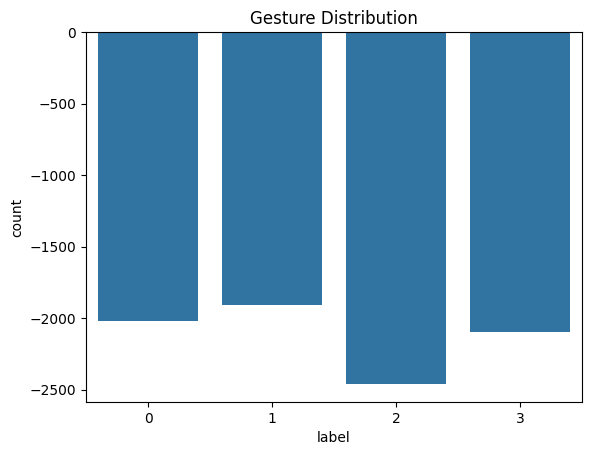


===== Logistic Regression =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       590
           1       1.00      1.00      1.00       603
           2       1.00      1.00      1.00       565
           3       1.00      1.00      1.00       578

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



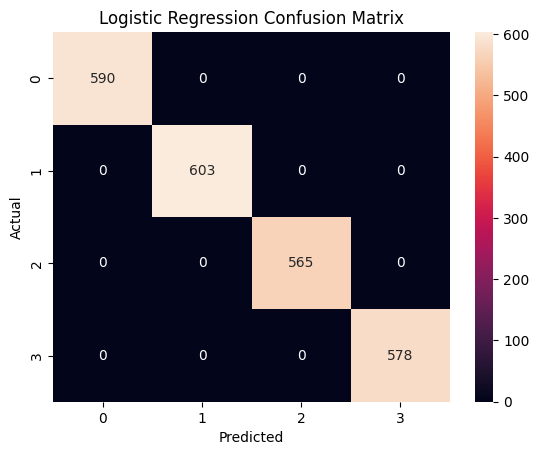


===== KNN =====
Accuracy: 0.769263698630137
              precision    recall  f1-score   support

           0       0.98      0.74      0.85       590
           1       0.64      1.00      0.78       603
           2       0.91      0.38      0.54       565
           3       0.77      0.94      0.84       578

    accuracy                           0.77      2336
   macro avg       0.82      0.76      0.75      2336
weighted avg       0.82      0.77      0.75      2336



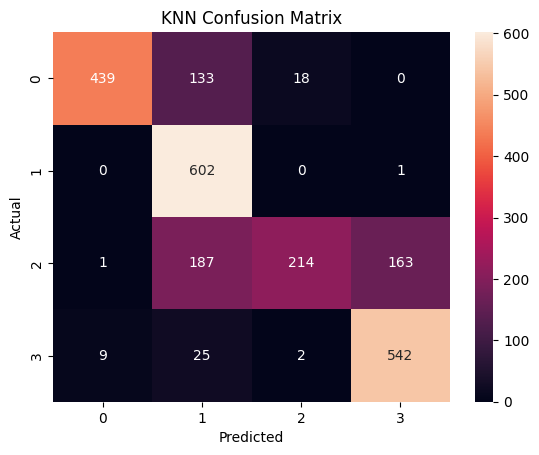


===== Decision Tree =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       590
           1       1.00      1.00      1.00       603
           2       1.00      1.00      1.00       565
           3       1.00      1.00      1.00       578

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



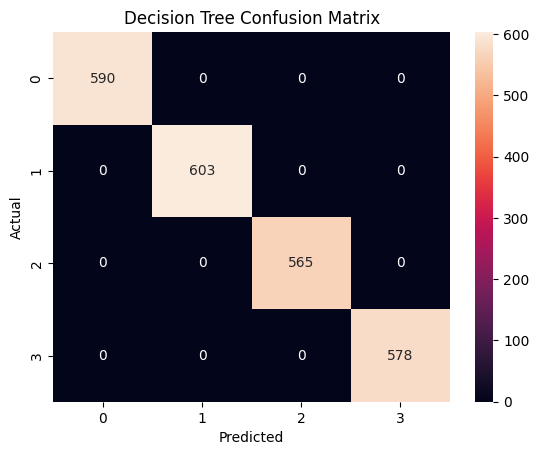


===== Random Forest =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       590
           1       1.00      1.00      1.00       603
           2       1.00      1.00      1.00       565
           3       1.00      1.00      1.00       578

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



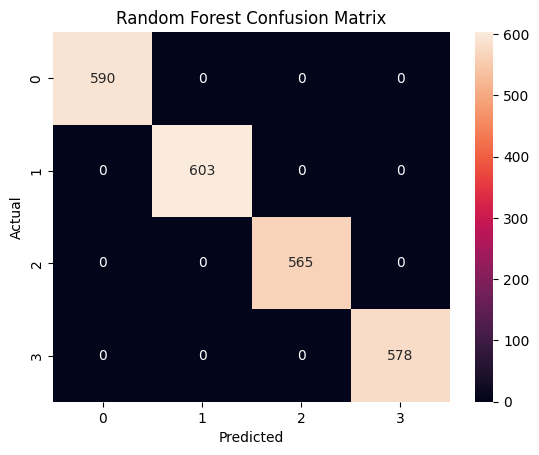


Final Accuracies:
Logistic Regression: 1.0
KNN: 0.769263698630137
Decision Tree: 1.0
Random Forest: 1.0


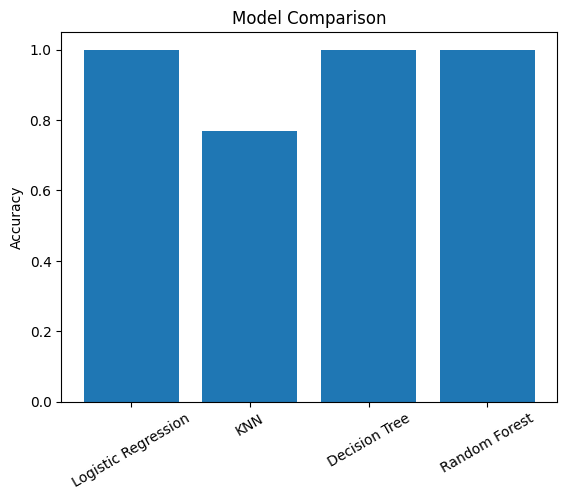

In [6]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# 2. LOAD ALL 4 DATA FILES
# =========================
df0 = pd.read_csv('0.csv', header=None)
df1 = pd.read_csv('1.csv', header=None)
df2 = pd.read_csv('2.csv', header=None)
df3 = pd.read_csv('3.csv', header=None)

# Add labels
df0['label'] = 0
df1['label'] = 1
df2['label'] = 2
df3['label'] = 3

# Combine dataset
df = pd.concat([df0, df1, df2, df3], ignore_index=True)

print("Dataset Shape:", df.shape)
print(df.head())

# =========================
# 3. EDA (Visualization)
# =========================
plt.figure()
sns.countplot(x='label', data=df)
plt.title("Gesture Distribution")
plt.show()

# =========================
# 4. PREPROCESSING
# =========================
X = df.drop('label', axis=1)
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 5. MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

# =========================
# 6. TRAIN + EVALUATE
# =========================
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================
# 7. FINAL COMPARISON
# =========================
print("\nFinal Accuracies:")
for model, acc in results.items():
    print(f"{model}: {acc}")

# Bar graph
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()